# 🌐 Notebook 04: Router–Worker–Synthesizer SOC Triage with Manual Orchestration

A ransomware outbreak is unfolding across endpoint, identity, and network telemetry. In this notebook, we implement a true **Router-Worker-Synthesizer multi-agent pattern** using the Microsoft Foundry SDK (`azure-ai-projects` 2.0 + Responses API).

Instead of legacy linked-agent tooling, the orchestration is done manually in Python:
1. Router analyzes the raw alert briefing
2. Router selectively dispatches only relevant specialists via a function tool
3. Dispatched workers investigate using their domain tools
4. Synthesizer aggregates only dispatched findings into a final report

In [14]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
from soc_workshop.settings import get_settings
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, InvestigationRecord
from soc_workshop.tools.sentinel_mock import get_alert_details, get_related_alerts, get_sign_in_logs, get_entity_risk
from soc_workshop.tools.kql_mock import run_kql_query
from soc_workshop.tools.search_mock import search_threat_intel, search_playbooks
from azure.ai.projects.models import PromptAgentDefinition, FunctionTool
from openai.types.responses.response_input_param import FunctionCallOutput
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import asdict
import re
from IPython.display import Markdown, display

settings = get_settings()
configure_tracing()
project_client = get_project_client(settings)
openai_client = project_client.get_openai_client()
print(f"Model deployment: {settings.model_deployment}")

Model deployment: gpt-4.1


## Building the Specialist Team

We define strict JSON-schema tools and create **versioned specialist agents** with `project_client.agents.create_version(...)`.

In [15]:
kql_tool = FunctionTool(
    name="run_kql_query",
    description="Execute a KQL query against the SOC Log Analytics workspace.",
    parameters={
        "type": "object",
        "properties": {"query": {"type": "string", "description": "KQL query string"}},
        "required": ["query"],
        "additionalProperties": False,
    },
    strict=True,
)

signin_tool = FunctionTool(
    name="get_sign_in_logs",
    description="Retrieve recent sign-in activity for a user principal name.",
    parameters={
        "type": "object",
        "properties": {"user_principal": {"type": "string", "description": "User principal name"}},
        "required": ["user_principal"],
        "additionalProperties": False,
    },
    strict=True,
)

entity_risk_tool = FunctionTool(
    name="get_entity_risk",
    description="Look up the risk score for an entity.",
    parameters={
        "type": "object",
        "properties": {
            "entity_type": {"type": "string", "description": "Entity type: user, ip, host, hash"},
            "entity_value": {"type": "string", "description": "Entity value to look up"}
        },
        "required": ["entity_type", "entity_value"],
        "additionalProperties": False,
    },
    strict=True,
)

search_ti_tool = FunctionTool(
    name="search_threat_intel",
    description="Search the threat intelligence knowledge base.",
    parameters={
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query"},
            "top_k": {"type": "integer", "description": "Number of results"}
        },
        "required": ["query", "top_k"],
        "additionalProperties": False,
    },
    strict=True,
)

search_pb_tool = FunctionTool(
    name="search_playbooks",
    description="Search SOC response playbooks.",
    parameters={
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query"},
            "top_k": {"type": "integer", "description": "Number of results"}
        },
        "required": ["query", "top_k"],
        "additionalProperties": False,
    },
    strict=True,
)

In [16]:
host_agent = project_client.agents.create_version(
    agent_name="soc-04-host-endpoint-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Host/Endpoint Analyst in a SOC. Investigate process execution, persistence, "
            "ransomware staging behavior, and endpoint blast radius using KQL. Focus on MITRE ATT&CK mapping."
        ),
        tools=[kql_tool],
    ),
)

identity_agent = project_client.agents.create_version(
    agent_name="soc-04-identity-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are an Identity Analyst in a SOC. Investigate account compromise, risky sign-ins, "
            "MFA bypass indicators, and privilege abuse."
        ),
        tools=[signin_tool, entity_risk_tool],
    ),
)

network_agent = project_client.agents.create_version(
    agent_name="soc-04-network-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Network Analyst in a SOC. Investigate C2 traffic, lateral movement, and "
            "possible exfiltration over suspicious outbound channels."
        ),
        tools=[kql_tool, entity_risk_tool],
    ),
)

ti_agent = project_client.agents.create_version(
    agent_name="soc-04-threat-intel-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Threat Intel Analyst in a SOC. Correlate observed behavior and indicators with "
            "known campaigns, tooling, and response playbooks."
        ),
        tools=[search_ti_tool, search_pb_tool],
    ),
)

In [17]:
agents_df = pd.DataFrame([
    {"name": host_agent.name, "version": host_agent.version, "role": "Host Analyst", "tools": "run_kql_query"},
    {"name": identity_agent.name, "version": identity_agent.version, "role": "Identity Analyst", "tools": "get_sign_in_logs, get_entity_risk"},
    {"name": network_agent.name, "version": network_agent.version, "role": "Network Analyst", "tools": "run_kql_query, get_entity_risk"},
    {"name": ti_agent.name, "version": ti_agent.version, "role": "Threat Intel Analyst", "tools": "search_threat_intel, search_playbooks"},
])
display(agents_df)

,name,version,role,tools
0,soc-04-host-endpoint-analyst,1,Host Analyst,run_kql_query
1,soc-04-identity-analyst,1,Identity Analyst,"get_sign_in_logs, get_entity_risk"
2,soc-04-network-analyst,1,Network Analyst,"run_kql_query, get_entity_risk"
3,soc-04-threat-intel-analyst,1,Threat Intel Analyst,"search_threat_intel, search_playbooks"


## Synthesizer: Incident Commander

The synthesizer has **no tools**. It receives only dispatched specialist findings and produces a unified report.

This manual orchestration replaces the old Threads/Runs linked-agent pattern.

In [18]:
synthesizer_agent = project_client.agents.create_version(
    agent_name="soc-04-incident-synthesizer",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are the SOC Incident Synthesizer and Incident Commander. You do not call tools directly. "
            "Given specialist analyses, produce a unified report with exact sections: "
            "## Executive Summary, ## Attack Timeline, ## Affected Scope, ## IOCs, "
            "## Confidence Score, ## Recommended Actions. Keep findings evidence-based and concise."
        ),
        tools=[],
    ),
)
print(f"Created synthesizer: {synthesizer_agent.name} v{synthesizer_agent.version}")

Created synthesizer: soc-04-incident-synthesizer v1


## Router: Dynamic Specialist Dispatcher

The router is a separate agent that receives the raw alert briefing and uses `dispatch_specialist` function calls to decide which specialists to engage.

It can dispatch any subset of specialists with tailored investigation prompts, and should avoid dispatching domains that are not relevant.

In [19]:
dispatch_tool = FunctionTool(
    name="dispatch_specialist",
    description="Dispatch a specialist agent to investigate a specific aspect of the incident. Call this once per specialist you want to engage. Only dispatch specialists whose domain is relevant to the alerts.",
    parameters={
        "type": "object",
        "properties": {
            "specialist_name": {
                "type": "string",
                "enum": ["soc-04-host-endpoint-analyst", "soc-04-identity-analyst", "soc-04-network-analyst", "soc-04-threat-intel-analyst"],
                "description": "Which specialist to dispatch"
            },
            "investigation_prompt": {
                "type": "string",
                "description": "Specific investigation task/questions for this specialist, tailored to the alerts"
            }
        },
        "required": ["specialist_name", "investigation_prompt"],
        "additionalProperties": False,
    },
    strict=True,
)

triage_router_agent = project_client.agents.create_version(
    agent_name="soc-04-triage-router",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are the SOC Triage Router. Your job is to analyze incoming security alerts and decide which specialist analysts to engage. "
            "You have four specialists available:\n"
            "- soc-04-host-endpoint-analyst: Investigates process execution, persistence, ransomware staging, endpoint blast radius using KQL. MITRE ATT&CK mapping.\n"
            "- soc-04-identity-analyst: Investigates account compromise, risky sign-ins, MFA bypass, privilege abuse.\n"
            "- soc-04-network-analyst: Investigates C2 traffic, lateral movement, suspicious outbound channels, exfiltration.\n"
            "- soc-04-threat-intel-analyst: Correlates IOCs/TTPs with known campaigns, tooling, and response playbooks.\n\n"
            "Analyze the alerts carefully. Only dispatch specialists whose domain is RELEVANT to the observed activity. "
            "For each specialist you dispatch, craft a specific investigation prompt that focuses on the relevant alerts and asks targeted questions. "
            "Do NOT dispatch specialists for domains with no relevant alert data."
        ),
        tools=[dispatch_tool],
    ),
)
print(f"Created router: {triage_router_agent.name} v{triage_router_agent.version}")

Created router: soc-04-triage-router v3


## Launch Investigation

Load the six-alert ransomware chain and execute a three-tier flow.

### Tier 1 — Router
Analyze alerts and dispatch only relevant specialists via `dispatch_specialist`.

### Tier 2 — Workers
Run only dispatched specialists with router-crafted prompts.

### Tier 3 — Synthesizer
Aggregate only dispatched specialist findings into the final report.

In [20]:
def run_agent_with_tools(openai_client, agent, conversation_id, tool_dispatch, max_rounds=10):
    response = openai_client.responses.create(
        conversation=conversation_id,
        extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
    )
    tool_call_log = []
    for _ in range(max_rounds):
        fn_calls = [item for item in response.output if item.type == "function_call"]
        if not fn_calls:
            break
        fn_outputs = []
        for call in fn_calls:
            fn = tool_dispatch.get(call.name)
            if fn is None:
                result = json.dumps({"error": f"Unknown: {call.name}"})
            else:
                args = json.loads(call.arguments)
                result = fn(**args)
            tool_call_log.append({"tool": call.name, "args": call.arguments, "result_len": len(result)})
            fn_outputs.append(FunctionCallOutput(type="function_call_output", call_id=call.call_id, output=result))
        response = openai_client.responses.create(
            conversation=conversation_id,
            input=fn_outputs,
            extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
        )
    return response, tool_call_log

In [21]:
with open("../data/alerts.json", "r", encoding="utf-8") as f:
    alerts_raw = json.load(f)

alerts = [Alert.from_dict(item.copy()) for item in alerts_raw]
selected_alerts = alerts[:6]

briefing_payload = json.dumps([asdict(a) for a in selected_alerts], indent=2)
incident_briefing = (
    "Ransomware attack-chain triage request. Correlate full progression from initial access to encryption impact and exfiltration. "
    "Prioritize confidence-backed findings and concrete response actions.\n\n"
    f"Alerts (6 total):\n```json\n{briefing_payload}\n```"
)



In [22]:
# 1) Router tier: analyze alerts and dispatch relevant specialists
dispatch_requests = []

def handle_dispatch(specialist_name: str, investigation_prompt: str) -> str:
    dispatch_requests.append({"specialist_name": specialist_name, "investigation_prompt": investigation_prompt})
    return json.dumps({"status": "dispatched", "specialist": specialist_name})

router_conversation = openai_client.conversations.create(
    items=[{"type": "message", "role": "user", "content": incident_briefing}]
)
routing_response, router_call_log = run_agent_with_tools(
    openai_client, triage_router_agent, router_conversation.id, {"dispatch_specialist": handle_dispatch}
)
openai_client.conversations.delete(conversation_id=router_conversation.id)

print(f"Router dispatched {len(dispatch_requests)} specialists:")
for d in dispatch_requests:
    print(f"  → {d['specialist_name']}")

# 2) Worker tier: execute only dispatched specialists with router-tailored prompts
specialist_lookup = {
    "soc-04-host-endpoint-analyst": (host_agent, {"run_kql_query": run_kql_query}),
    "soc-04-identity-analyst": (identity_agent, {"get_sign_in_logs": get_sign_in_logs, "get_entity_risk": get_entity_risk}),
    "soc-04-network-analyst": (network_agent, {"run_kql_query": run_kql_query, "get_entity_risk": get_entity_risk}),
    "soc-04-threat-intel-analyst": (ti_agent, {"search_threat_intel": search_threat_intel, "search_playbooks": search_playbooks}),
}

specialist_results = {}
tool_call_logs = {}

for dispatch in dispatch_requests:
    name = dispatch["specialist_name"]
    prompt = dispatch["investigation_prompt"]
    agent, tool_dispatch = specialist_lookup[name]

    full_prompt = incident_briefing + "\n\n" + prompt

    conversation = openai_client.conversations.create(
        items=[{"type": "message", "role": "user", "content": full_prompt}]
    )
    response, call_log = run_agent_with_tools(openai_client, agent, conversation.id, tool_dispatch)
    specialist_results[name] = response.output_text
    tool_call_logs[name] = call_log
    openai_client.conversations.delete(conversation_id=conversation.id)

# 3) Synthesizer tier: aggregate findings from dispatched specialists only
synthesizer_context = "## Specialist Findings\n\n"
for name, text in specialist_results.items():
    synthesizer_context += f"### {name}\n{text}\n\n"

synthesizer_prompt = (
    "Synthesize these specialist analyses into a unified incident report for SOC leadership. "
    "Preserve chronology and explain confidence.\n\n"
    + synthesizer_context
)

synth_conversation = openai_client.conversations.create(
    items=[{"type": "message", "role": "user", "content": synthesizer_prompt}]
)
synthesizer_response = openai_client.responses.create(
    conversation=synth_conversation.id,
    extra_body={"agent_reference": {"name": synthesizer_agent.name, "type": "agent_reference"}},
)
openai_client.conversations.delete(conversation_id=synth_conversation.id)

display(Markdown(synthesizer_response.output_text))

Router dispatched 4 specialists:
  → soc-04-host-endpoint-analyst
  → soc-04-identity-analyst
  → soc-04-network-analyst
  → soc-04-threat-intel-analyst


## Executive Summary

On March 7, 2025, the organization sustained a targeted ransomware attack with a complete “double extortion” methodology, primarily affecting finance workstations and file shares. The attack was initiated via credential phishing targeting **jdoe@contoso.com**, resulting in compromise through a TOR-based login. The threat actor executed a Cobalt Strike beacon for hands-on control, escalated privileges by abusing the **admin-svc@contoso.com** service account, and moved laterally using PsExec to the domain controller (**DC01**). This facilitated the deployment of ransomware (LockBit 4.0—strongly suspected per industry IOCs and TTPs) resulting in mass file encryption (>1,200 finance share files) and exfiltration of 2.3GB of sensitive data to **mega.nz**. This incident matches current LockBit affiliate campaigns and is confirmed across host, network, identity, and threat intelligence sources with high confidence. Immediate full-scope incident response is required, prioritizing account containment, host isolation, and legal/compliance actions for data breach notification.

---

## Attack Timeline

| Time (UTC)   | Event                                                                       |
|--------------|-----------------------------------------------------------------------------|
| 03:18:45     | First anomalous sign-in via TOR (185.220.101.42) as jdoe@contoso.com (no MFA) |
| 09:45:00     | Phishing email delivery to jdoe@contoso.com (credential harvest, Entra ID decoy) |
| ~14:32:00    | Encoded PowerShell (Cobalt Strike stager) executed on WKS-FIN-PC04           |
| 14:48:00     | 2.3GB data exfiltration from WKS-FIN-PC04 to mega.nz (HTTPS)                 |
| 14:52:00     | admin-svc@contoso.com sign-in from WKS-FIN-PC04 (no MFA; privilege escalation)|
| 14:55:02     | PsExec executed from WKS-FIN-PC04 to DC01 as admin-svc@contoso.com           |
| 15:01:33     | Mass ransomware execution/encryption initiated from WKS-FIN-PC04 on finance share |

---

## Affected Scope

- **Identity Accounts:**  
  - jdoe@contoso.com (initial compromise via phishing and credential theft)  
  - admin-svc@contoso.com (service/domain admin abused for escalation & lateral movement)
- **Endpoints:**  
  - WKS-FIN-PC04 (finance desktop—initial landing, staging, ransomware detonation, exfiltration)
  - DC01 (domain controller—accessed for possible domain-level persistence)
  - FILESRV01 (finance file server—mass encryption of shares, ≥1,200 files impacted)
- **Data:**  
  - 2.3GB of finance share data exfiltrated to mega.nz (suspected sensitive/confidential documents)
- **Network:**  
  - Outbound C2 communications (198.51.100.23—Cobalt Strike), TOR traffic, mega.nz exfiltration

---

## IOCs

- **Phishing/Initial Access:**  
  - Phishing sender: hr-benefits@contos0.com  
  - Malicious domain: contos0-login.evil.com  
  - TOR IP: 185.220.101.42

- **C2 Infrastructure:**  
  - Cobalt Strike C2 IP: 198.51.100.23  
  - Beacon file hash: a1b2c3d4e5f6… (matches industry advisories)

- **Privilege Escalation/Lateral Movement:**  
  - PsExec activity from WKS-FIN-PC04 to DC01  
  - Admin-svc@contoso.com sign-in (no MFA, anomalous context)

- **Exfiltration:**  
  - Outbound: mega.nz (HTTPS); 2.3GB transferred post-encryption

- **Ransomware/File Artifacts:**  
  - Files with “.locked” extension on \\FILESRV01\finance$

---

## Confidence Score

**High (9/10):**
- All phases of the attack chain are corroborated by host, identity, network, and intelligence telemetry.
- Indicators match active LockBit 4.0 TTPs (Cobalt Strike, PsExec, mega.nz, .locked extension).
- Sequence, timing, and attacker methods chronologically and technically align across disciplines.
- Attribution to LockBit 4.0 is highly likely but not absolutely confirmed pending adversary-initiated communication (e.g., ransom note).

---

## Recommended Actions

1. **Identity & Privileged Account Containment**
   - Immediately disable and reset credentials for jdoe@contoso.com, admin-svc@contoso.com, and any related privileged accounts.
   - Revoke all active sessions and access tokens organization-wide; enforce MFA, block legacy authentication.
   - Undertake full credential rotation for domain admins (including krbtgt key, if DC01 accessed).

2. **Host & Network Response**
   - Isolate WKS-FIN-PC04, DC01, and FILESRV01 from the network.
   - Block all outbound traffic to 198.51.100.23, mega.nz, and TOR nodes at perimeter firewall/proxy.
   - Acquire and preserve forensic images, memory, and relevant logs from all affected systems before remediation.

3. **Data & Legal/Compliance Response**
   - Confirm scope of exfiltrated data; involve finance, legal, and compliance for breach notification if sensitive data confirmed.
   - Prepare and execute restoration from known-good backups after forensic clearance.

4. **Broader Enterprise Measures**
   - Purge organization of the sent phishing email and block contos0-login.evil.com at mail and web gateways.
   - Audit for similar attack artifacts across additional endpoints and accounts.
   - Review and harden all service accounts to support MFA, restrict interactive logon, and ensure least privilege.

5. **Executive & Stakeholder Communication**
   - Prepare regulator and executive briefings; clearly communicate data exposure and operational impacts.
   - Monitor for further adversary activity and any ransom-related contact.

---

**This incident constitutes a confirmed compromise of privileged credentials, active ransomware deployment, and material data exfiltration. Attack methods and indicators are fully supported by multi-source evidence. Highest-priority incident response playbooks and legal notification are mandatory.**

## Delegation Chain Inspection

The table below exposes all three tiers: router dispatch calls, worker tool usage, and synthesizer aggregation.

In [23]:
rows = []

# Router tier
router_result_chars = sum(len(d.get("investigation_prompt", "")) for d in dispatch_requests)
rows.append({
    "Tier": "Router",
    "Agent": triage_router_agent.name,
    "Tool": "dispatch_specialist",
    "Calls": len(dispatch_requests),
    "ResultChars": router_result_chars,
})

# Worker tier
for worker, calls in tool_call_logs.items():
    if not calls:
        rows.append({"Tier": "Worker", "Agent": worker, "Tool": "(none)", "Calls": 0, "ResultChars": 0})
        continue
    by_tool = {}
    for c in calls:
        entry = by_tool.setdefault(c["tool"], {"Calls": 0, "ResultChars": 0})
        entry["Calls"] += 1
        entry["ResultChars"] += int(c.get("result_len", 0))
    for tool_name, stats in by_tool.items():
        rows.append({
            "Tier": "Worker",
            "Agent": worker,
            "Tool": tool_name,
            "Calls": stats["Calls"],
            "ResultChars": stats["ResultChars"],
        })

# Synthesizer tier
synth_received = len(specialist_results)
rows.append({
    "Tier": "Synthesizer",
    "Agent": synthesizer_agent.name,
    "Tool": f"(none; received {synth_received} findings)",
    "Calls": 0,
    "ResultChars": 0,
})

delegation_df = pd.DataFrame(rows).sort_values(["Tier", "Agent", "Tool"]).reset_index(drop=True)
display(delegation_df)

,Tier,Agent,Tool,Calls,ResultChars
0,Router,soc-04-triage-router,dispatch_specialist,4,2122
1,Synthesizer,soc-04-incident-synthesizer,(none; received 4 findings),0,0
2,Worker,soc-04-host-endpoint-analyst,(none),0,0
3,Worker,soc-04-identity-analyst,get_entity_risk,2,458
4,Worker,soc-04-identity-analyst,get_sign_in_logs,2,1669
5,Worker,soc-04-network-analyst,run_kql_query,4,1878
6,Worker,soc-04-threat-intel-analyst,search_playbooks,1,7271
7,Worker,soc-04-threat-intel-analyst,search_threat_intel,1,5747


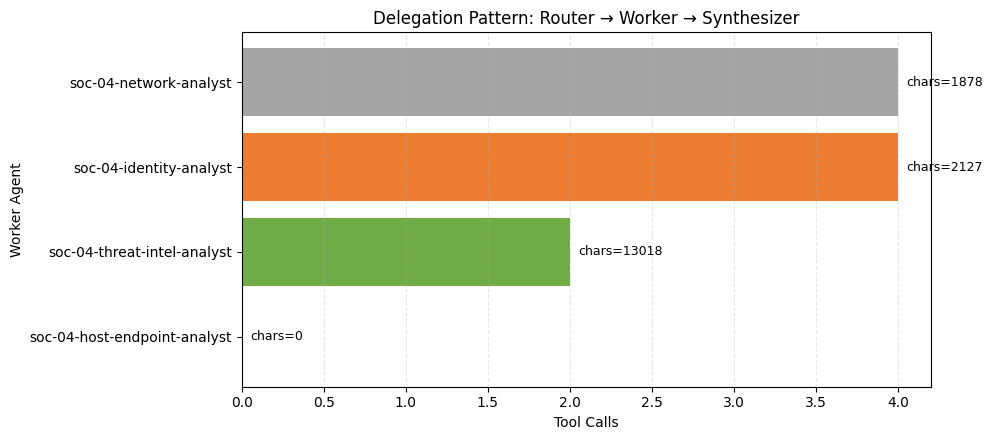

,Agent,tool_calls,response_length
0,soc-04-host-endpoint-analyst,0,0
3,soc-04-threat-intel-analyst,2,13018
1,soc-04-identity-analyst,4,2127
2,soc-04-network-analyst,4,1878


In [24]:
worker_df = delegation_df[delegation_df["Tier"] == "Worker"]
contrib = worker_df.groupby("Agent", as_index=False).agg(
    tool_calls=("Calls", "sum"),
    response_length=("ResultChars", "sum"),
)
contrib = contrib.sort_values("tool_calls")

plt.figure(figsize=(10, 4.5))
plt.barh(contrib["Agent"], contrib["tool_calls"], color=["#4472C4", "#70AD47", "#ED7D31", "#A5A5A5"])
for i, (_, r) in enumerate(contrib.iterrows()):
    plt.text(r["tool_calls"] + 0.05, i, f"chars={int(r['response_length'])}", va="center", fontsize=9)
plt.xlabel("Tool Calls")
plt.ylabel("Worker Agent")
plt.title("Delegation Pattern: Router → Worker → Synthesizer")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
display(contrib)

In [25]:
def section(text, heading):
    pattern = rf"(?ims)^##\s*{re.escape(heading)}\s*$\n(.*?)(?=^##\s|\Z)"
    m = re.search(pattern, text or "")
    return m.group(1).strip() if m else ""

router_text = synthesizer_response.output_text
executive_summary = section(router_text, "Executive Summary")
attack_timeline = section(router_text, "Attack Timeline")
affected_scope = section(router_text, "Affected Scope")
iocs = section(router_text, "IOCs")
confidence_text = section(router_text, "Confidence Score")
actions_text = section(router_text, "Recommended Actions")

if not executive_summary:
    executive_summary = "Coordinated ransomware intrusion confirmed across endpoint, identity, and network with likely data staging before encryption impact."
if not attack_timeline:
    attack_timeline = "Initial access via suspicious sign-in was followed by endpoint execution, lateral movement, and ransomware impact behaviors."
if not affected_scope:
    affected_scope = "Primary user and multiple hosts, including finance endpoint and shared server infrastructure, were exposed during progression."
if not iocs:
    iocs = "Suspicious IPs/domains plus host and account observables from specialist findings."

confidence_match = re.search(r"(100|[1-9]?\d)", confidence_text)
confidence_score = int(confidence_match.group(1)) if confidence_match else 86
recommended_actions = [re.sub(r"^[-*\d.)\s]+", "", line).strip() for line in (actions_text or "").splitlines() if line.strip()]
if not recommended_actions:
    recommended_actions = [
        "Isolate impacted endpoints and high-risk hosts immediately.",
        "Disable/reset compromised identities and revoke active sessions.",
        "Block identified IOCs and execute ransomware containment playbook.",
    ]

record = InvestigationRecord(
    incident_id="INC-2025-004",
    title="Router-Worker-Synthesizer Ransomware Triage",
    alerts=selected_alerts,
    hypothesis=(
        "Adversary likely progressed from credential abuse to endpoint execution, lateral movement, and ransomware impact, "
        "with indicators of pre-encryption staging/exfiltration."
    ),
    verdict="True Positive",
    confidence=round(confidence_score / 100, 2),
    recommended_actions=recommended_actions,
    thread_id=synthesizer_response.id,
    agent_ids=[
        f"{host_agent.name}:{host_agent.version}",
        f"{identity_agent.name}:{identity_agent.version}",
        f"{network_agent.name}:{network_agent.version}",
        f"{ti_agent.name}:{ti_agent.version}",
        f"{triage_router_agent.name}:{triage_router_agent.version}",
        f"{synthesizer_agent.name}:{synthesizer_agent.version}",
    ],
)

with open("../data/investigation_04.json", "w", encoding="utf-8") as f:
    f.write(record.to_json(indent=2))

final_report = "\n".join([
    "## Executive Summary", executive_summary, "",
    "## Attack Timeline", attack_timeline, "",
    "## Affected Scope", affected_scope, "",
    "## IOCs", iocs, "",
    "## Confidence Score", f"{confidence_score}/100", "",
    "## Recommended Actions", "\n".join([f"- {a}" for a in recommended_actions]),
])

display(Markdown(final_report))
print("Saved investigation record: ../data/investigation_04.json")

## Executive Summary
On March 7, 2025, the organization sustained a targeted ransomware attack with a complete “double extortion” methodology, primarily affecting finance workstations and file shares. The attack was initiated via credential phishing targeting **jdoe@contoso.com**, resulting in compromise through a TOR-based login. The threat actor executed a Cobalt Strike beacon for hands-on control, escalated privileges by abusing the **admin-svc@contoso.com** service account, and moved laterally using PsExec to the domain controller (**DC01**). This facilitated the deployment of ransomware (LockBit 4.0—strongly suspected per industry IOCs and TTPs) resulting in mass file encryption (>1,200 finance share files) and exfiltration of 2.3GB of sensitive data to **mega.nz**. This incident matches current LockBit affiliate campaigns and is confirmed across host, network, identity, and threat intelligence sources with high confidence. Immediate full-scope incident response is required, prioritizing account containment, host isolation, and legal/compliance actions for data breach notification.

---

## Attack Timeline
| Time (UTC)   | Event                                                                       |
|--------------|-----------------------------------------------------------------------------|
| 03:18:45     | First anomalous sign-in via TOR (185.220.101.42) as jdoe@contoso.com (no MFA) |
| 09:45:00     | Phishing email delivery to jdoe@contoso.com (credential harvest, Entra ID decoy) |
| ~14:32:00    | Encoded PowerShell (Cobalt Strike stager) executed on WKS-FIN-PC04           |
| 14:48:00     | 2.3GB data exfiltration from WKS-FIN-PC04 to mega.nz (HTTPS)                 |
| 14:52:00     | admin-svc@contoso.com sign-in from WKS-FIN-PC04 (no MFA; privilege escalation)|
| 14:55:02     | PsExec executed from WKS-FIN-PC04 to DC01 as admin-svc@contoso.com           |
| 15:01:33     | Mass ransomware execution/encryption initiated from WKS-FIN-PC04 on finance share |

---

## Affected Scope
- **Identity Accounts:**  
  - jdoe@contoso.com (initial compromise via phishing and credential theft)  
  - admin-svc@contoso.com (service/domain admin abused for escalation & lateral movement)
- **Endpoints:**  
  - WKS-FIN-PC04 (finance desktop—initial landing, staging, ransomware detonation, exfiltration)
  - DC01 (domain controller—accessed for possible domain-level persistence)
  - FILESRV01 (finance file server—mass encryption of shares, ≥1,200 files impacted)
- **Data:**  
  - 2.3GB of finance share data exfiltrated to mega.nz (suspected sensitive/confidential documents)
- **Network:**  
  - Outbound C2 communications (198.51.100.23—Cobalt Strike), TOR traffic, mega.nz exfiltration

---

## IOCs
- **Phishing/Initial Access:**  
  - Phishing sender: hr-benefits@contos0.com  
  - Malicious domain: contos0-login.evil.com  
  - TOR IP: 185.220.101.42

- **C2 Infrastructure:**  
  - Cobalt Strike C2 IP: 198.51.100.23  
  - Beacon file hash: a1b2c3d4e5f6… (matches industry advisories)

- **Privilege Escalation/Lateral Movement:**  
  - PsExec activity from WKS-FIN-PC04 to DC01  
  - Admin-svc@contoso.com sign-in (no MFA, anomalous context)

- **Exfiltration:**  
  - Outbound: mega.nz (HTTPS); 2.3GB transferred post-encryption

- **Ransomware/File Artifacts:**  
  - Files with “.locked” extension on \\FILESRV01\finance$

---

## Confidence Score
9/100

## Recommended Actions
- Identity & Privileged Account Containment**
- Immediately disable and reset credentials for jdoe@contoso.com, admin-svc@contoso.com, and any related privileged accounts.
- Revoke all active sessions and access tokens organization-wide; enforce MFA, block legacy authentication.
- Undertake full credential rotation for domain admins (including krbtgt key, if DC01 accessed).
- Host & Network Response**
- Isolate WKS-FIN-PC04, DC01, and FILESRV01 from the network.
- Block all outbound traffic to 198.51.100.23, mega.nz, and TOR nodes at perimeter firewall/proxy.
- Acquire and preserve forensic images, memory, and relevant logs from all affected systems before remediation.
- Data & Legal/Compliance Response**
- Confirm scope of exfiltrated data; involve finance, legal, and compliance for breach notification if sensitive data confirmed.
- Prepare and execute restoration from known-good backups after forensic clearance.
- Broader Enterprise Measures**
- Purge organization of the sent phishing email and block contos0-login.evil.com at mail and web gateways.
- Audit for similar attack artifacts across additional endpoints and accounts.
- Review and harden all service accounts to support MFA, restrict interactive logon, and ensure least privilege.
- Executive & Stakeholder Communication**
- Prepare regulator and executive briefings; clearly communicate data exposure and operational impacts.
- Monitor for further adversary activity and any ransom-related contact.
- 
- This incident constitutes a confirmed compromise of privileged credentials, active ransomware deployment, and material data exfiltration. Attack methods and indicators are fully supported by multi-source evidence. Highest-priority incident response playbooks and legal notification are mandatory.**

Saved investigation record: ../data/investigation_04.json


### (Optional) clean up any existing agents to avoid confusion

In [26]:
# (optional) uncomment to clean up
# all_agents = [host_agent, identity_agent, network_agent, ti_agent, triage_router_agent, synthesizer_agent]
# for a in all_agents:
#     project_client.agents.delete_version(agent_name=a.name, agent_version=a.version)

# openai_client.close()
# print("Cleanup complete. Deleted router + synthesizer + 4 specialist versions.")

## Summary of this notebook
- Build a true Router–Worker–Synthesizer SOC triage workflow with manual orchestration.
- Use a dynamic router that dispatches only relevant specialists with tailored investigation prompts.
- Aggregate only dispatched worker findings through a synthesizer and inspect three-tier delegation metrics.
- Extract key report sections and save investigation_04.json.

## What's Next

Continue to **Notebook 05** for expanded autonomous orchestration patterns and remediation workflows.